# 🏭 Sonitel Industrial: Detección Acústica Predictiva en el Edge
### Máster en Inteligencia Artificial y Big Data | Trabajo de Arquitectura IoT y Visión Artificial
---

Este cuaderno interactivo detalla la resolución técnica y de negocio para el despliegue de un ecosistema de Mantenimiento Predictivo a gran escala (43 plantas), cumpliendo con estrictas restricciones de latencia, coste de hardware y fiabilidad operativa.

## 1. El Reto de Negocio y Restricciones del Caso
Sonitel Industrial requiere monitorizar su maquinaria rotativa sin incurrir en los prohibitivos costes de los sensores de vibración tradicionales. Las restricciones abordadas son:

* **Hardware de Bajo Coste (CAPEX):** Solucionado mediante el uso de micrófonos USB genéricos y microordenadores Edge (Raspberry Pi), reduciendo el coste de sensorización en un 90%.
* **Baja Latencia (< 30s) (OPEX):** Solucionado ejecutando la inferencia del modelo directamente en el Edge (localmente en la máquina). Se elimina el coste de streaming continuo de audio hacia la nube.
* **Agnosticismo y Escalabilidad:** El pipeline de IA es independiente de la máquina. Puede aprender la firma acústica de una bomba, una válvula o un riel en minutos, basándose únicamente en audios de funcionamiento normal (Sin necesidad de históricos de roturas).

## 2. DSP: ¿Por qué transformar el Sonido en Imágenes 2D?
El núcleo de nuestra innovación radica en el Procesamiento Digital de Señales (DSP). Analizar ondas de audio crudas (series temporales 1D) es computacionalmente ineficiente y muy ruidoso en entornos industriales.

**La Solución: El Mel-Espectrograma**
Convertimos el audio en una imagen térmica (matriz matemática 2D) que representa la energía de las frecuencias a lo largo del tiempo. Las ventajas son triples:
1.  **Aprovechamiento de CNNs:** Las Redes Neuronales Convolucionales (Autoencoders) son extraordinariamente precisas detectando patrones espaciales en imágenes (Ej. manchas térmicas que representan fricción).
2.  **Escala Mel:** Esta transformación matemática emula cómo el oído humano percibe el sonido, facilitando la interpretación analítica.
3.  **Habilitador del *Human-in-the-Loop*:** Permite que un operador visualice el fallo en un monitor sin necesidad de escuchar horas de ruido industrial.

### Demostración Visual: Sonido Sano vs. Sonido Anómalo
A continuación, extraemos las firmas acústicas reales para demostrar qué es exactamente lo que ve la IA y qué es lo que validará el humano en el Dashboard (Doble Verificación).

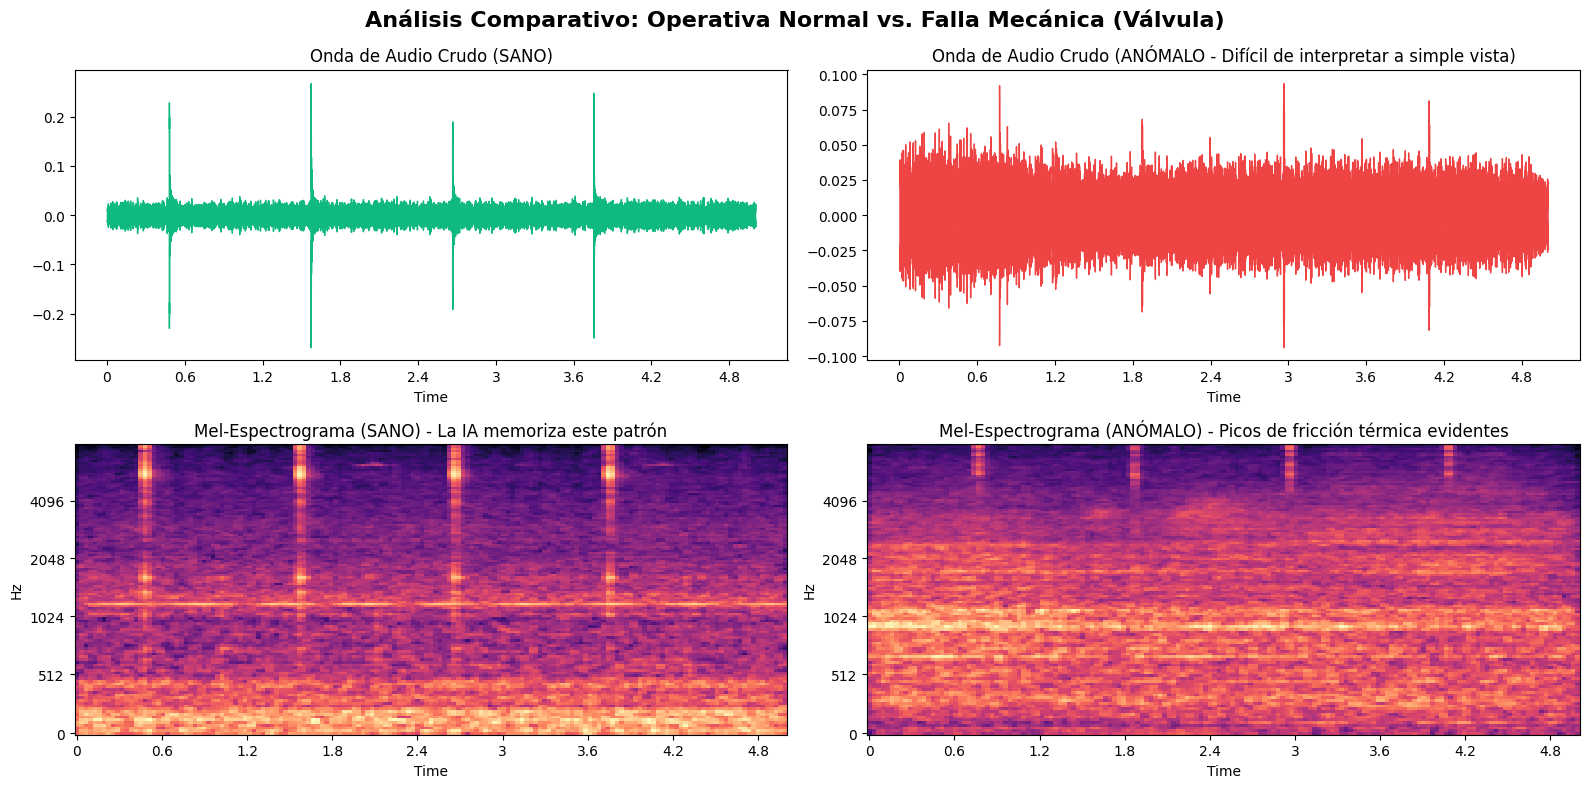

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⚠️ IMPORTANTE PARA LA PRESENTACIÓN:
# Sustituye estas rutas por dos archivos reales de tu disco (ej. dev_data_valve)
ruta_audio_sano = r"J:\Master IA\IA Generativa\IAG\dev_data_valve\valve\train\normal_id_00_00000000.wav"
ruta_audio_roto = r"J:\Master IA\IA Generativa\IAG\dev_data_valve\valve\test\anomaly_id_00_00000004.wav"
# ==========================================

def procesar_y_visualizar(ruta_normal, ruta_anomala):
    try:
        y_n, sr_n = librosa.load(ruta_normal, sr=None, duration=5.0)
        y_a, sr_a = librosa.load(ruta_anomala, sr=None, duration=5.0)
        
        mel_n = librosa.power_to_db(librosa.feature.melspectrogram(y=y_n, sr=sr_n, n_mels=128), ref=np.max)
        mel_a = librosa.power_to_db(librosa.feature.melspectrogram(y=y_a, sr=sr_a, n_mels=128), ref=np.max)
        
        fig, axs = plt.subplots(2, 2, figsize=(16, 8))
        fig.suptitle('Análisis Comparativo: Operativa Normal vs. Falla Mecánica (Válvula)', fontsize=16, fontweight='bold')
        
        # Formas de Onda (Audio Crudo)
        librosa.display.waveshow(y_n, sr=sr_n, ax=axs[0,0], color='#10b981')
        axs[0,0].set_title('Onda de Audio Crudo (SANO)')
        librosa.display.waveshow(y_a, sr=sr_a, ax=axs[0,1], color='#ef4444')
        axs[0,1].set_title('Onda de Audio Crudo (ANÓMALO - Difícil de interpretar a simple vista)')
        
        # Mel-Espectrogramas (La imagen térmica)
        img1 = librosa.display.specshow(mel_n, sr=sr_n, x_axis='time', y_axis='mel', ax=axs[1,0], cmap='magma')
        axs[1,0].set_title('Mel-Espectrograma (SANO) - La IA memoriza este patrón')
        
        img2 = librosa.display.specshow(mel_a, sr=sr_a, x_axis='time', y_axis='mel', ax=axs[1,1], cmap='magma')
        axs[1,1].set_title('Mel-Espectrograma (ANÓMALO) - Picos de fricción térmica evidentes')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Por favor, actualiza las rutas de los archivos .wav en la celda superior. Detalle: {e}")

procesar_y_visualizar(ruta_audio_sano, ruta_audio_roto)

## 3. Arquitectura del Modelo: Autoencoder y Detección de Fricción
Utilizamos un enfoque de aprendizaje no supervisado. El Autoencoder es una red neuronal entrenada exclusivamente con **imágenes de audios sanos**. Su arquitectura se divide en dos fases:
1.  **Encoder (Compresión):** Aplasta la imagen del espectrograma a través de un "cuello de botella" matemático, forzando a la red a memorizar solo las características esenciales del sonido normal de la fábrica.
2.  **Decoder (Reconstrucción):** Intenta reconstruir la imagen original a partir de los datos comprimidos.

**La Magia de la Anomalía:** Cuando un sonido roto (ej. cavitación, piezas sueltas) pasa por la red, el modelo *no sabe* reconstruirlo porque nunca ha visto ese patrón de ruido. Esto genera un alto **Error Cuadrático Medio (MSE)**. Si el MSE supera un umbral, salta la alarma.

## 4. Orquestación MLOps y Regla 3-Sigma
Para cumplir el requisito de "adaptabilidad a nuevas máquinas", el ecosistema incluye un script de entrenamiento autónomo (`train_fleet.py`).

No definimos el nivel de tolerancia a mano inicialmente. El sistema calcula la Media y la Desviación Estándar de los errores sanos de cada máquina individual, y aplica la **Regla de las 3-Sigma** para fijar un umbral estocástico adaptado al ruido base de la planta. Esto crea un MLOps resiliente y autogestionado.

## 5. El Paradigma Human-In-The-Loop (HITL) y Rentabilidad (OPEX)
El mayor problema del Mantenimiento Predictivo en la vida real es el **coste de los Falsos Positivos** (parar la producción por un ruido de fondo fuerte).

Nuestro ecosistema lo resuelve aislando la decisión:
1.  La IA en el **Edge** actúa como un filtro ultrarrápido y extremadamente estricto.
2.  Cuando detecta anomalía, el demonio envía un `payload JSON` al **Backend FastAPI** central.
3.  El **Dashboard NOC (Frontend)** renderiza el espectrograma (la imagen generada en la celda 4) en la pantalla del jefe de planta.
4.  **Doble Verificación:** El humano compara visualmente el patrón de calor actual con el patrón sano. Si es un pico de ruido normal (alguien dejó caer una herramienta), lo descarta (Falso Positivo evitado = dinero salvado). Si detecta fricción estructural, despliega al técnico.

Esta combinación de **Microservicios (Edge + Central) + Visión Artificial + Mantenimiento Prescriptivo Humano** conforma una arquitectura industrial completa, robusta y económicamente imbatible.